# Data

In [1]:
import h5py
import scanpy as sc

In [2]:
data_path = "/Users/bdepouilly/CompBio/multiome-vae/data/raw"
adata = sc.read_10x_h5(f"{data_path}/10k_PBMC_Multiome_nextgem_Chromium_X_filtered_feature_bc_matrix.h5", gex_only=False)
adata.var_names_make_unique()

/Users/bdepouilly/CompBio/multiome-vae/venv/lib/python3.14/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [3]:
# Separate gene expression and peaks

adata_rna = adata[:, adata.var["feature_types"] == "Gene Expression"].copy()
adata_atac = adata[:, adata.var["feature_types"] == "Peaks"].copy()

In [4]:
adata_rna.var["mt"] = adata_rna.var_names.str.startswith("MT-")
adata_rna.var["rib"] = adata_rna.var_names.str.startswith(("RPS", "RPL"))
adata_rna.var["hb"] = adata_rna.var_names.str.contains("^HB[^(P)]")

In [5]:
sc.pp.calculate_qc_metrics(adata_rna, qc_vars=["mt", "rib", "hb"], inplace=True)

In [6]:
adata_rna.shape

(10970, 36601)

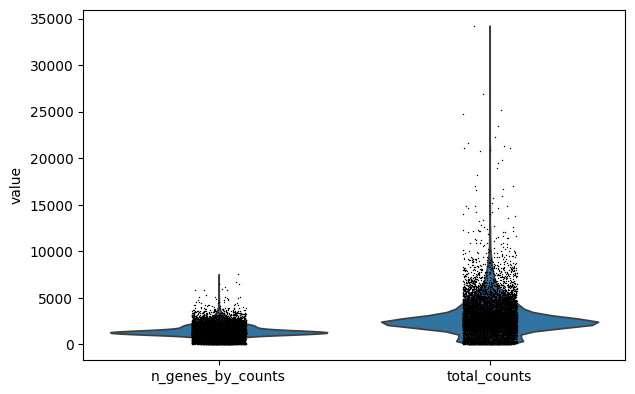

In [7]:
sc.pl.violin(adata_rna, ["n_genes_by_counts", "total_counts"])

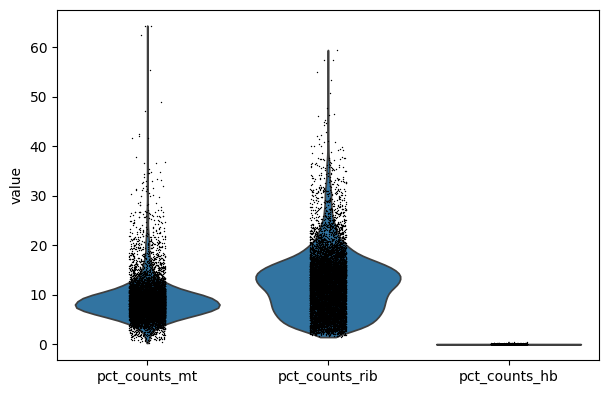

In [8]:
sc.pl.violin(adata_rna, ["pct_counts_mt", "pct_counts_rib", "pct_counts_hb"])

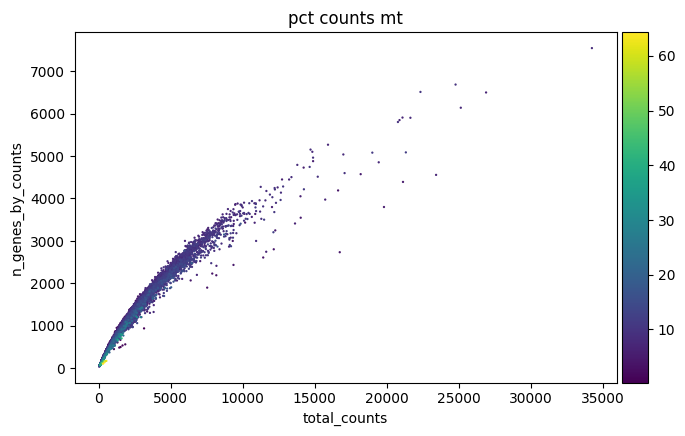

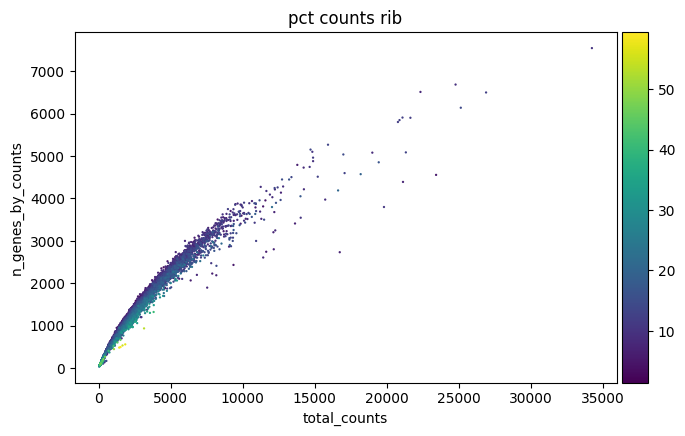

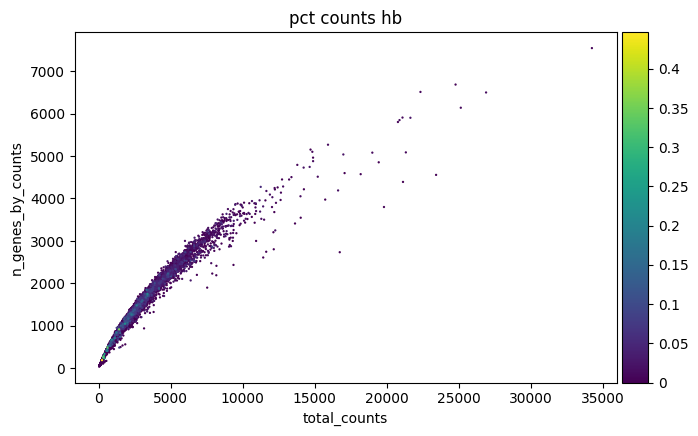

In [9]:
sc.pl.scatter(adata_rna, "total_counts", "n_genes_by_counts", color="pct_counts_mt")
sc.pl.scatter(adata_rna, "total_counts", "n_genes_by_counts", color="pct_counts_rib")
sc.pl.scatter(adata_rna, "total_counts", "n_genes_by_counts", color="pct_counts_hb")

In [10]:
sc.pp.filter_cells(adata_rna, min_genes=100)
sc.pp.filter_genes(adata_rna, min_cells=3)
sc.pp.scrublet(adata_rna)

In [11]:
import numpy as np

def is_outlier(adata, metric: str, nmads: int, genes: bool = False): #if genes is true we filter out genes, otherwise we filter out cells/barcodes
    if genes: m = adata.var[metric]
    else: m = adata.obs[metric]
    mad = np.median(np.abs(m - np.median(m)))
    outlier = (m > np.median(m) + nmads*mad) | (m < np.median(m) - nmads*mad)
    return outlier

In [12]:
mask_cells = (is_outlier(adata_rna, "log1p_total_counts", 5) | is_outlier(adata_rna, "log1p_n_genes_by_counts", 5) | is_outlier(adata_rna, "pct_counts_in_top_50_genes", 5))
adata_rna.obs["outlier"] = mask_cells
adata_rna.obs['outlier'].value_counts()

outlier
False    9866
True      983
Name: count, dtype: int64

In [13]:
mask_cells_mt = is_outlier(adata_rna, "pct_counts_mt", 5) | (adata_rna.obs['pct_counts_mt'] > 10)
adata_rna.obs['mt_outlier'] = mask_cells_mt

In [14]:
print(f"Number of cells pre-filtering: {adata_rna.n_obs}.")
adata_rna = adata_rna[(~adata_rna.obs.outlier) & (~adata_rna.obs.mt_outlier)].copy()

print(f"Number of cells after filtering: {adata_rna.n_obs}.")

Number of cells pre-filtering: 10849.
Number of cells after filtering: 7485.


In [15]:
# Keep the same cells for atac and rna analysis

common_barcodes = adata_rna.obs_names.intersection(adata_atac.obs_names)

adata_rna = adata_rna[common_barcodes].copy()
adata_atac = adata_atac[common_barcodes].copy()

In [16]:
# Saving count data
adata_rna.layers['counts'] = adata_rna.X.copy()

# Normalizing to median total coutns
sc.pp.normalize_total(adata_rna)
# Log-transform the data
sc.pp.log1p(adata_rna)

In [17]:
adata_rna

AnnData object with n_obs × n_vars = 7485 × 25664
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_rib', 'log1p_total_counts_rib', 'pct_counts_rib', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'outlier', 'mt_outlier'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'rib', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'scrublet', 'log1p'
    layers: 'counts'

In [18]:
sc.pp.highly_variable_genes(adata_rna, n_top_genes=5000)

In [25]:
type(adata)

anndata._core.anndata.AnnData

In [28]:
rna = sc.read_h5ad("/Users/bdepouilly/CompBio/multiome-vae/data/processed/adata_rna_processed.h5ad")
print("cells:", rna.n_obs)
print("genes:", rna.n_vars)
print("has counts layer:", "counts" in rna.layers)
print("mt_outlier in obs:", "mt_outlier" in rna.obs)
print("outlier in obs:", "outlier" in rna.obs)
print("HVGs:", int(rna.var.get("highly_variable", []).sum()))

cells: 7485
genes: 5000
has counts layer: True
mt_outlier in obs: True
outlier in obs: True
HVGs: 5000


In [51]:
atac = adata_atac.copy()

In [52]:
sc.pp.filter_genes(atac, min_cells=20)

In [ ]:
from sklearn.preprocessing import normalize

X = atac.X

X_tf = normalize(X, norm='l1', axis=1)

n_cells = X_tf.shape[0]
peak_counts = np.array((X_tf > 0).sum(axis=0)).flatten()
idf = np.log(1 + n_cells / (1 + peak_counts))

X_tfidf = X_tf.multiply(idf)
X_tfidf = np.log1p(X_tfidf)

In [56]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=256)
X_atac_lsi = svd.fit_transform(X_tfidf)

In [45]:
sc.pp.calculate_qc_metrics(atac, inplace=True)
atac

AnnData object with n_obs × n_vars = 7485 × 111743
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

<Axes: ylabel='n_cells_by_counts'>

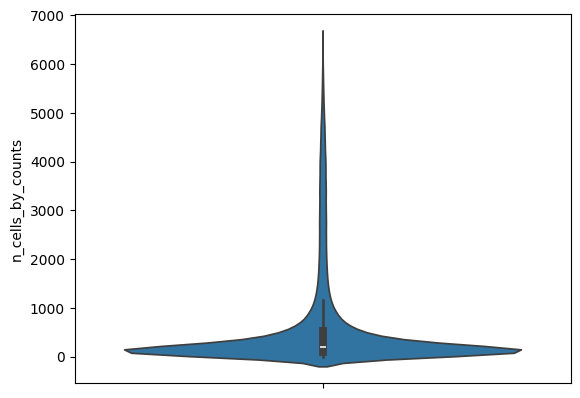

In [50]:
import seaborn as sns

sns.violinplot(y=atac.var["n_cells_by_counts"])